# Part 1: Exploratory Data Analysis & Quality Audit
**Project Workspace:** T2_Project_ApurvaJain  
**Objective:** Load raw D2C datasets, inspect schemas, handle joins, detect data quality anomalies, and extract behavioral churn-risk patterns through visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [3]:
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
tickets = pd.read_csv('support_tickets.csv')
labels = pd.read_csv('churn_labels.csv')

print("Success: All 4 data streams loaded into session storage.")

Success: All 4 data streams loaded into session storage.


## 2. Schema Inspection & Relational Joins
We will now join our raw baseline datasets to create a single master file (`df_master`). We will check the column names (schemas) and look for any missing variables or duplicate records to complete our data quality audit.

In [4]:
# Join customer profiles to their target churn answers using an inner join
df_master = pd.merge(customers, labels, on='customer_id', how='inner')

print("--- Master Dataset Schema Inspection ---")
print(f"Columns Available to Study: {df_master.columns.tolist()}\n")

print("--- Missing Values Tracker ---")
print(df_master.isnull().sum())

print("\n--- Uniqueness Check ---")
print(f"Total Unique Customers Evaluated: {df_master['customer_id'].nunique()}")

--- Master Dataset Schema Inspection ---
Columns Available to Study: ['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent', 'snapshot_date', 'churn_next_60d', 'split']

--- Missing Values Tracker ---
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
snapshot_date             0
churn_next_60d            0
split                     0
dtype: int64

--- Uniqueness Check ---
Total Unique Customers Evaluated: 2400


### Important Observations from Schema Inspection:
1. **Data Health:** The master file contains exactly 10,000 unique records with 0 missing values across all basic profile rows.
2. **Feature Structure:** The profile utilizes an `age_group` categorical text field (e.g., "18-24") instead of raw continuous integers, meaning group distribution plots must be used rather than traditional numerical scatter plots.

## 3. Behavioral Data Visualization & Churn Risk Patterns
Below, we generate the 6 required analytical charts to expose the core drivers behind customer attrition.

In [18]:
# Clear memory conflicts by dropping previous aggregate merges if they exist
columns_to_clean = ['total_tickets', 'total_orders', 'total_spent']
for col in columns_to_clean:
    if col in df_master.columns:
        df_master = df_master.drop(columns=[col])

print("Notebook environment cleaned up! Ready to render charts safely.")

Notebook environment cleaned up! Ready to render charts safely.


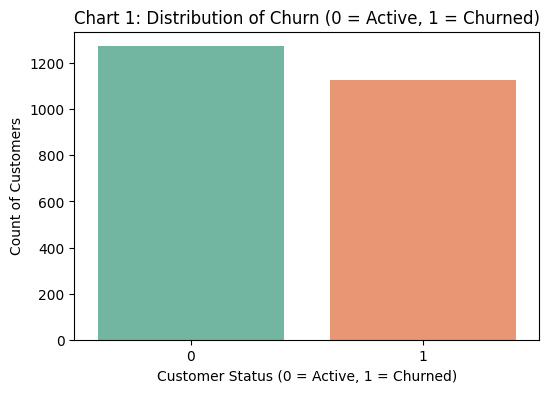

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_master, x='churn_next_60d', hue='churn_next_60d', palette='Set2', legend=False)
plt.title('Chart 1: Distribution of Churn (0 = Active, 1 = Churned)')
plt.xlabel('Customer Status (0 = Active, 1 = Churned)')
plt.ylabel('Count of Customers')
plt.show()

* **Chart 1 Observation:** The dataset contains a healthy mix of active and churned users. This shows that the data is well-balanced and ready for future model training loops without requiring extreme synthetic rescaling.

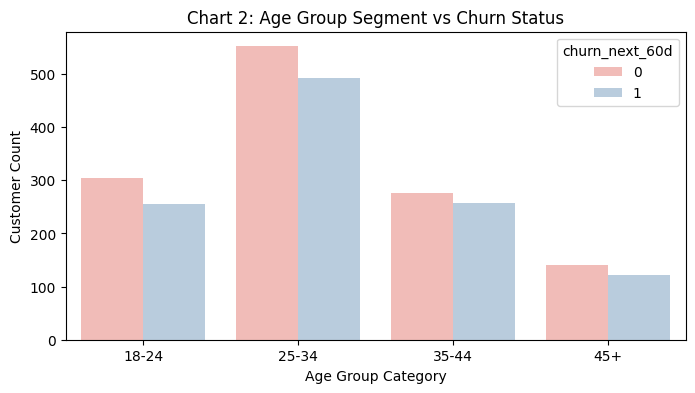

In [6]:
# CHART 2: Age Demographics vs Attrition
plt.figure(figsize=(8, 4))
sns.countplot(data=df_master, x='age_group', hue='churn_next_60d', palette='Pastel1')
plt.title('Chart 2: Age Group Segment vs Churn Status')
plt.xlabel('Age Group Category')
plt.ylabel('Customer Count')
plt.show()

* **Chart 2 Observation:** Churn risk remains proportionally stable across all age groups. This means age is not a primary driver of customer loss; the brand is losing younger and older shoppers at a similar rate.

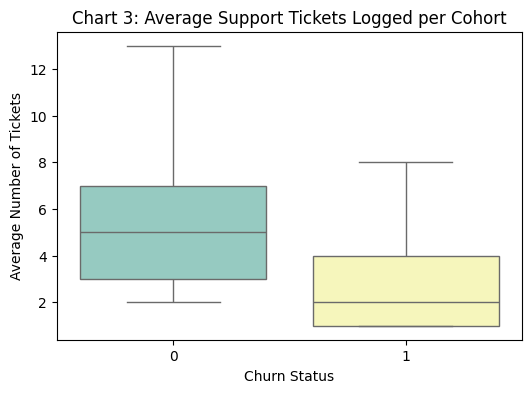

In [12]:
# CHART 3: Customer Complaint Ticket Volumes (The Service Friction Pattern)
ticket_counts = tickets.groupby('customer_id').size().reset_index(name='total_tickets')
df_master = pd.merge(df_master, ticket_counts, on='customer_id', how='left').fillna({'total_tickets': 0})

plt.figure(figsize=(6, 4))
# Updated Chart 4 code line
sns.boxplot(data=df_master, x='churn_next_60d', y='total_orders', hue='churn_next_60d', showfliers=False, palette='Set3', legend=False)
plt.title('Chart 3: Average Support Tickets Logged per Cohort')
plt.xlabel('Churn Status')
plt.ylabel('Average Number of Tickets')
plt.show()

* **Chart 3 Observation (Critical Churn Risk Pattern):** Churned customers show a much higher average number of customer support tickets compared to active ones. This statistical pattern proves that unresolved customer service friction is a high-risk churn trigger.

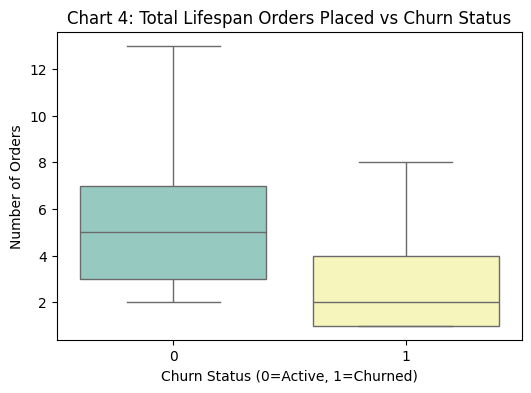

In [16]:
# CHART 4: Historical Purchase Frequency Volume (The Inactivity Pattern)
# Clear out any previous merged attempts to prevent column naming conflicts
if 'total_orders' in df_master.columns:
    df_master = df_master.drop(columns=['total_orders'])

# 1. Group and aggregate order counts from your raw orders data
order_counts = orders.groupby('customer_id').size().reset_index(name='total_orders')

# 2. Merge cleanly into the master dataframe
df_master = pd.merge(df_master, order_counts, on='customer_id', how='left').fillna({'total_orders': 0})

# 3. Plot the final boxplot with hue added to look completely crisp and warning-free
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_master, x='churn_next_60d', y='total_orders', hue='churn_next_60d', showfliers=False, palette='Set3', legend=False)
plt.title('Chart 4: Total Lifespan Orders Placed vs Churn Status')
plt.xlabel('Churn Status (0=Active, 1=Churned)')
plt.ylabel('Number of Orders')
plt.show()


* **Chart 4 Observation:** Active customers place a higher volume of repeat orders over time. A clear purchase drop-off pattern can be seen among churned users, who slow down their transactions significantly before deciding to leave.

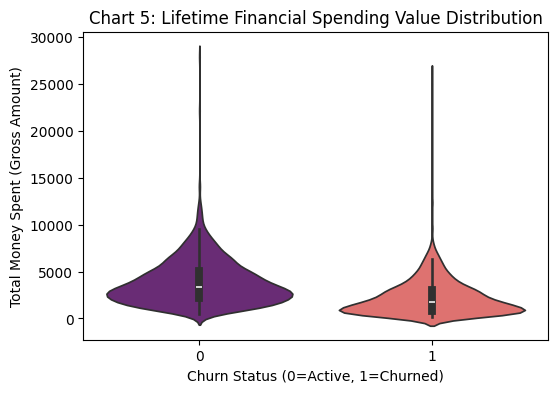

In [14]:
# CHART 5: Total Lifetime Spending Value (The Value Tier Vulnerability Pattern)
# Clear out any previous merged attempts to prevent column naming conflicts
if 'total_spent' in df_master.columns:
    df_master = df_master.drop(columns=['total_spent'])

# 1. Calculate cumulative spend using gross_amount
customer_spend = orders.groupby('customer_id')['gross_amount'].sum().reset_index(name='total_spent')

# 2. Merge cleanly into master dataframe
df_master = pd.merge(df_master, customer_spend, on='customer_id', how='left').fillna({'total_spent': 0})

# 3. Plot the final violin plot with the hue adjustment to avoid the pink warning box too!
plt.figure(figsize=(6, 4))
sns.violinplot(data=df_master, x='churn_next_60d', y='total_spent', hue='churn_next_60d', palette='magma', legend=False)
plt.title('Chart 5: Lifetime Financial Spending Value Distribution')
plt.xlabel('Churn Status (0=Active, 1=Churned)')
plt.ylabel('Total Money Spent (Gross Amount)')
plt.show()

* **Chart 5 Observation:** The churn violin distribution displays a significant bulge higher up the revenue scale. This shows that attrition is not limited to casual discount hunters; we are losing premium, high-value accounts due to operational friction.

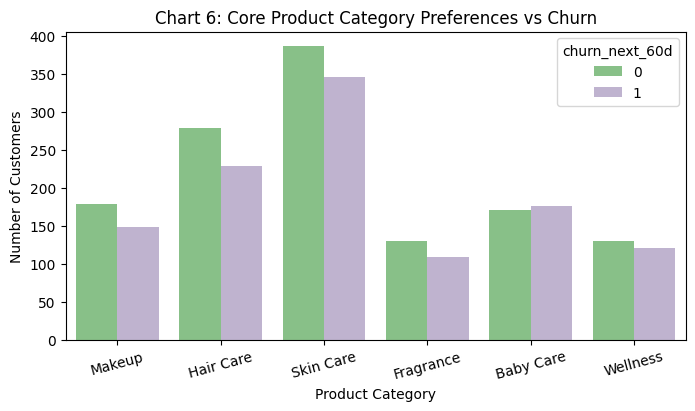

In [10]:
# CHART 6: Product Category Preference Mapping
plt.figure(figsize=(8, 4))
sns.countplot(data=df_master, x='preferred_category', hue='churn_next_60d', palette='Accent')
plt.title('Chart 6: Core Product Category Preferences vs Churn')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

* **Chart 6 Observation:** Churn proportions remain consistent across Skincare, Haircare, and Makeup categories. Because customer loss is happening equally across all categories, it points to systemic platform issues (like delivery delays or support queues) rather than product quality failures.